# 221. Maximal Square
https://leetcode.com/problems/maximal-square/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DP (1D array) | $O(mn)$ | $O(n)$ | Optimal space |
| DP (2D array) | $O(mn)$ | $O(mn)$ | Classic approach |
| Brute force | $O(mn \cdot \min(m,n)^2)$ | $O(1)$ | Expand from each cell |

## Methodology

Use DP where `dp[i][j]` represents the side length of the largest square whose bottom-right corner is at (i,j). If `matrix[i][j] == '1'`, then `dp[i][j] = min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]) + 1`. Track the maximum side length and return its square as the area. Optimize to 1D array since we only need the previous row.

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaximalSquare(char[][] matrix) {
        int m = matrix.Length, n = matrix[0].Length;
        int[] dp = new int[n + 1];
        int maxSide = 0, prev = 0;
        for (int i = 0; i < m; i++) {
            for (int j = 1; j <= n; j++) {
                int temp = dp[j];
                if (matrix[i][j - 1] == '1') {
                    dp[j] = Math.Min(Math.Min(dp[j - 1], dp[j]), prev) + 1;
                    maxSide = Math.Max(maxSide, dp[j]);
                } else {
                    dp[j] = 0;
                }
                prev = temp;
            }
            prev = 0;
        }
        return maxSide * maxSide;
    }
}

### Python

In [ ]:
class Solution:
    def maximalSquare(self, matrix: list[list[str]]) -> int:
        m, n = len(matrix), len(matrix[0])
        dp = [0] * (n + 1)
        max_side = 0
        prev = 0
        for i in range(m):
            for j in range(1, n + 1):
                temp = dp[j]
                if matrix[i][j - 1] == '1':
                    dp[j] = min(dp[j - 1], dp[j], prev) + 1
                    max_side = max(max_side, dp[j])
                else:
                    dp[j] = 0
                prev = temp
            prev = 0
        return max_side * max_side

### Go

In [ ]:
func maximalSquare(matrix [][]byte) int {
    m, n := len(matrix), len(matrix[0])
    dp := make([]int, n+1)
    maxSide, prev := 0, 0
    for i := 0; i < m; i++ {
        for j := 1; j <= n; j++ {
            temp := dp[j]
            if matrix[i][j-1] == '1' {
                dp[j] = min(dp[j-1], min(dp[j], prev)) + 1
                maxSide = max(maxSide, dp[j])
            } else {
                dp[j] = 0
            }
            prev = temp
        }
        prev = 0
    }
    return maxSide * maxSide
}

### Rust

In [ ]:
impl Solution {
    pub fn maximal_square(matrix: Vec<Vec<char>>) -> i32 {
        let (m, n) = (matrix.len(), matrix[0].len());
        let mut dp = vec![0i32; n + 1];
        let mut max_side = 0;
        let mut prev = 0;
        for i in 0..m {
            for j in 1..=n {
                let temp = dp[j];
                if matrix[i][j - 1] == '1' {
                    dp[j] = dp[j - 1].min(dp[j]).min(prev) + 1;
                    max_side = max_side.max(dp[j]);
                } else {
                    dp[j] = 0;
                }
                prev = temp;
            }
            prev = 0;
        }
        max_side * max_side
    }
}

## Example Scenarios

### 1. Common Case — Mixed Matrix with 2x2 Square
**Input:** `matrix = [["1","0","1","0","0"],["1","0","1","1","1"],["1","1","1","1","1"],["1","0","0","1","0"]]`

The DP builds up from single cells. At $(2,3)$, all three neighbors (left, above, diagonal) have $dp \ge 1$, so $dp[2][3] = \min(1,1,1) + 1 = 2$, indicating a $2 \times 2$ square of 1s with bottom-right corner at $(2,3)$.

WHY tricky: The $\min$ of three neighbors is the key insight — a square can **only grow** if ALL three adjacent sub-squares exist. One zero neighbor caps the square size.

$dp[i][j] = \min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]) + 1$. Area $= 2^2 = 4$. **Output:** `4`

---

### 2. Slightly Complex — Diagonal 1s (No 2x2 Square)
**Input:** `matrix = [["1","0","0"],["0","1","0"],["0","0","1"]]`

1s appear only on the diagonal. Each cell with a 1 has at least one 0 neighbor (above or left), so dp never exceeds 1. Despite having three 1s, no $2 \times 2$ all-1s square exists.

WHY tricky: Many 1s but **strategically placed** to prevent any $2 \times 2$ square. Tests that the algorithm correctly requires ALL three neighbors, not just one or two.

For every $(i,j)$ with `matrix[i][j]='1'`: $\min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]) = 0 \Rightarrow dp = 1$. **Output:** `1`

---

### 3. Edge Case: Time — Full 300x300 Matrix of 1s
**Input:** `matrix = [["1"]*300 for _ in range(300)]` (300x300 all 1s)

Every cell is '1'. The DP value grows from 1 at edges to 300 at $(299,299)$. We compute dp for all 90,000 cells, each requiring a constant-time $\min$ of three neighbors. The answer is $300^2 = 90{,}000$.

WHY tricky: Maximum matrix size tests $O(mn)$ time. The maximum dp value equals $\min(m,n) = 300$, and the entire matrix is one giant square.

$m \times n = 300 \times 300 = 90{,}000$ operations. Answer $= 300^2 = 90{,}000$. **Output:** `90000`

---

### 4. Edge Case: Space — Single Row
**Input:** `matrix = [["1","1","1","1","1"]]` (1x5)

A single row means no cell has a row above it. Each dp value is at most 1 since there are no vertical neighbors. With 1D DP optimization, the array has only $n+1 = 6$ entries.

WHY tricky: The 1D DP optimization uses $O(n)$ space, but when $m=1$, every $dp[j] = 1$ since there is no "above" or "diagonal" neighbor. Maximum square is $1 \times 1$.

Space: $O(n) = O(5)$ with 1D optimization. $\text{max\_side} = 1$. **Output:** `1`

---

### 5. Almost Impossible — Entire Matrix is '0'
**Input:** `matrix = [["0"]*300 for _ in range(300)]` (300x300 all 0s)

No cell contains '1', so every dp value is 0. The algorithm scans all 90,000 cells but $\text{max\_side}$ remains 0 throughout. The result is $0^2 = 0$.

WHY tricky: Boundary test — ensures the algorithm correctly returns **0** (not -1 or undefined) when no square of 1s exists. $\text{max\_side}$ is never updated from its initial value.

$\text{max\_side} = 0$ throughout. Area $= 0^2 = 0$. **Output:** `0`

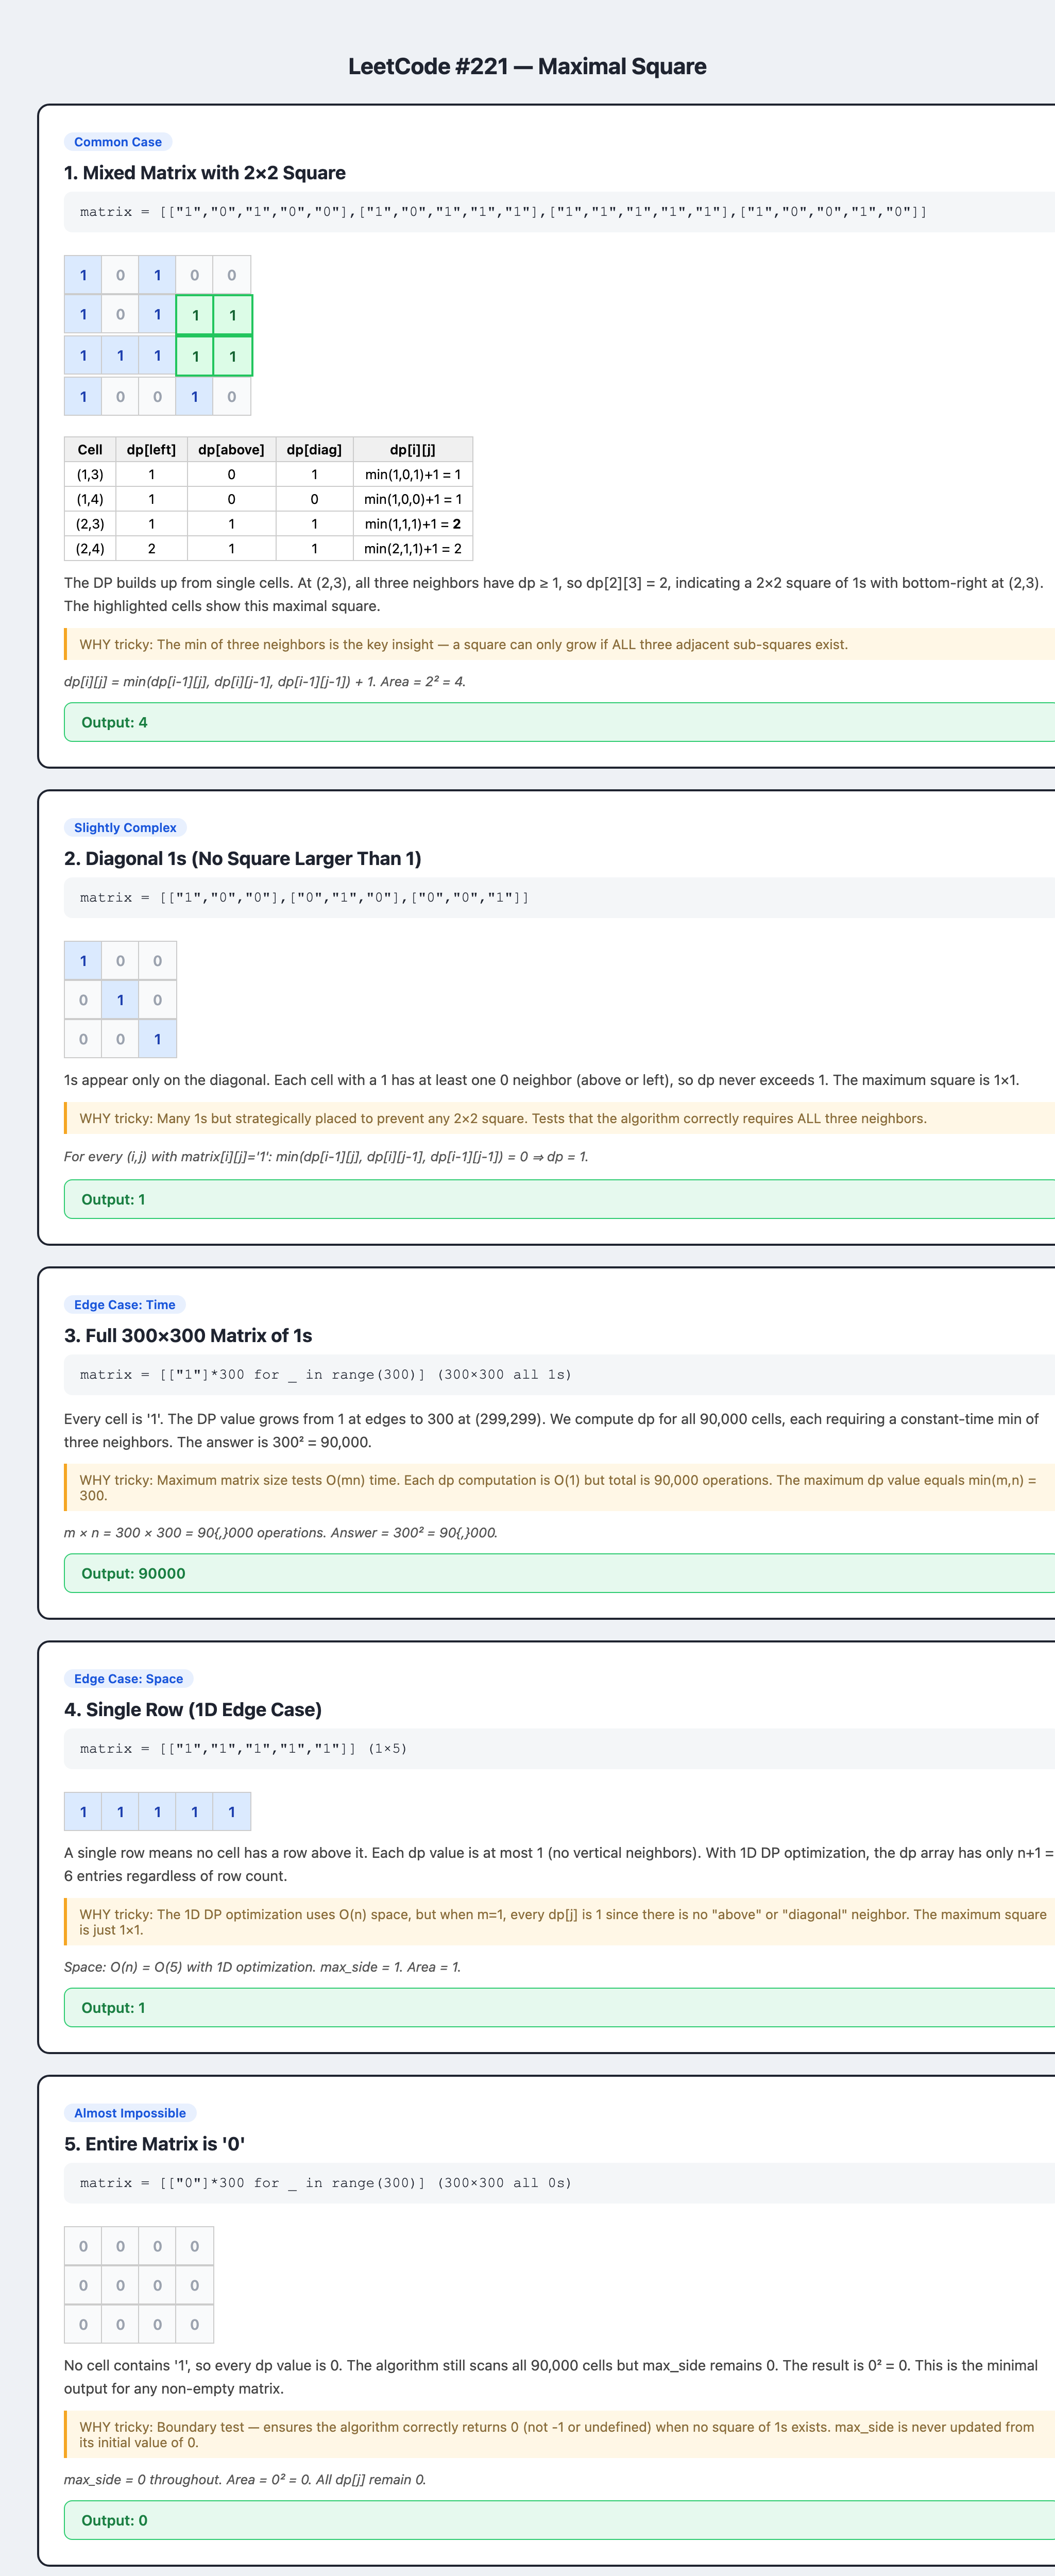